# Block 1
## Laden der Daten

In [4]:
import pandas as pd
import numpy as np
import openpyxl

# === Dateien einlesen ===
calls = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\calls_cleaned062.xlsx',
    engine='openpyxl'
).copy()

contacts = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\contacts_cleaned062.xlsx',
    engine='openpyxl'
).copy()

spend = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\spend_cleaned062.xlsx',
    engine='openpyxl'
).copy()

deals = pd.read_excel(
    r'C:\Users\Acer\Projekt\Output\deals_cleaned062.xlsx',
    engine='openpyxl'
).copy()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
print("Loaded shapes:")
print("calls   :", calls.shape)
print("contacts:", contacts.shape)
print("spend   :", spend.shape)
print("deals   :", deals.shape)

Loaded shapes:
calls   : (95874, 9)
contacts: (18548, 4)
spend   : (19612, 7)
deals   : (21591, 25)


# Block 2

## 1. Berechnung der deskriptiven Statistik für numerische Felder

Berechnen Sie für numerische Variablen folgende Kennzahlen:

* **Mittelwert (Mean)**
* **Median**
* **Modus**
* **Wertebereich (Range = Max − Min)**

Diese Kennzahlen helfen, die zentrale Tendenz und die Streuung der Daten zu verstehen.

### 2. Analyse kategorialer Variablen

Analysieren Sie kategoriale Felder wie:

* **Quality**
* **Stage**
* **Source**
* **Product**

Für diese Variablen sollten Sie die **Häufigkeitsverteilung** (Counts und Prozentanteile) untersuchen, um zu verstehen, welche Kategorien am häufigsten vorkommen und wie sich die Daten über die Kategorien verteilen.

### 2.1. Berechnen Sie die deskriptive Statistik (Mittelwert, Median, Modus, Wertebereich) für numerische Felder.

In [8]:
import pandas as pd
import numpy as np

# === Funktionen für statistische Kennzahlen ===
def numeric_columns(df, exclude=None):
    """
    Gibt numerische Spalten zurück,
    außer denen, die in 'exclude' angegeben sind.
    """
    if exclude is None:
        exclude = []

    return [
        col for col in df.select_dtypes(include=np.number).columns
        if col not in exclude
    ]


def summary_statistics(df, exclude=None):
    """
    Deskriptive Statistik:
    - Mittelwert (mean)
    - Median
    - einfacher Modus (mode)
    - Wertebereich (range)
    """
    cols = numeric_columns(df, exclude)

    if not cols:
        return pd.DataFrame()  # sicherer Rückgabewert, falls keine numerischen Spalten existieren

    summary = pd.DataFrame(index=cols)

    summary['mean'] = df[cols].mean()
    summary['median'] = df[cols].median()

    # einfacher Modus (erstes vorkommendes Modalwert)
    summary['mode'] = [
        df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
        for col in cols
    ]

    summary['range'] = [
        df[col].max() - df[col].min()
        for col in cols
    ]

    return summary

In [9]:
dataframes = {
    'calls': calls,
    'contacts': contacts,
    'spend': spend,
    'deals': deals
}

exclude_cols = ['Id', 'Contact Name', 'ContactID', 'CONTACTID']

stats_all = {
    name: summary_statistics(df, exclude=exclude_cols)
    for name, df in dataframes.items()
}

pd.set_option('display.float_format', '{:.2f}'.format)

for name, stats in stats_all.items():
    print(f"=== {name.upper()} STATISTICS ===\n")
    print(stats, "\n")

=== CALLS STATISTICS ===

                             mean  median  mode   range
Call Duration (in seconds) 164.98    8.00  0.00 7625.00 

=== CONTACTS STATISTICS ===

Empty DataFrame
Columns: []
Index: [] 

=== SPEND STATISTICS ===

                         mean  median  mode     range
Impressions           2604.47   89.00  0.00 431445.00
Spend                    7.62    0.79  0.00    774.00
Clicks                  25.42    2.00  0.00   2415.00
Campaign_missing_flag    0.26    0.00  0.00      1.00 

=== DEALS STATISTICS ===

                        mean   median     mode    range
Course duration        10.20    11.00    11.00     5.00
Months of study         5.45     5.00     6.00    11.00
Initial Amount Paid   950.07  1000.00  1000.00 11500.00
Offer Total Amount   7128.72 11000.00 11000.00 11500.00
SLA_days               15.01     4.00     0.00   335.00
Closed_same_day_flag    0.22     0.00     0.00     1.00
SLA_negative_flag       0.00     0.00     0.00     0.00 



In [11]:
# Boxplots für numerische Spalten erstellen
def plot_boxplots(df, exclude=None, title_prefix="", plots_per_row=3):
    if exclude is None:
        exclude = []

    # Numerische Spalten auswählen (ohne ausgeschlossene Spalten)
    num_cols = [
        c for c in df.select_dtypes(include=np.number).columns
        if c not in exclude
    ]

    if not num_cols:
        print(f"{title_prefix}: Keine numerischen Spalten für Boxplots vorhanden.")
        return

    n_cols = plots_per_row
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    plt.figure(figsize=(5 * n_cols, 3 * n_rows))

    for i, col in enumerate(num_cols, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        s = pd.to_numeric(df[col], errors="coerce").dropna()

        if len(s) > 0:
            ax.boxplot(s, vert=False)
            ax.set_title(col)
        else:
            ax.text(0.5, 0.5, "Keine Daten", ha="center", va="center")
            ax.set_title(col)

    plt.suptitle(f"{title_prefix} – Boxplots", y=1.02)
    plt.tight_layout()
    plt.show()

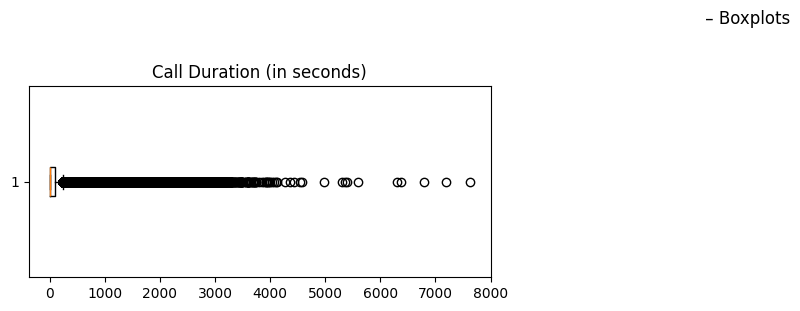

In [13]:
plot_boxplots(
    calls,
    exclude=['Id', 'ContactID', 'CONTACTID'],
)

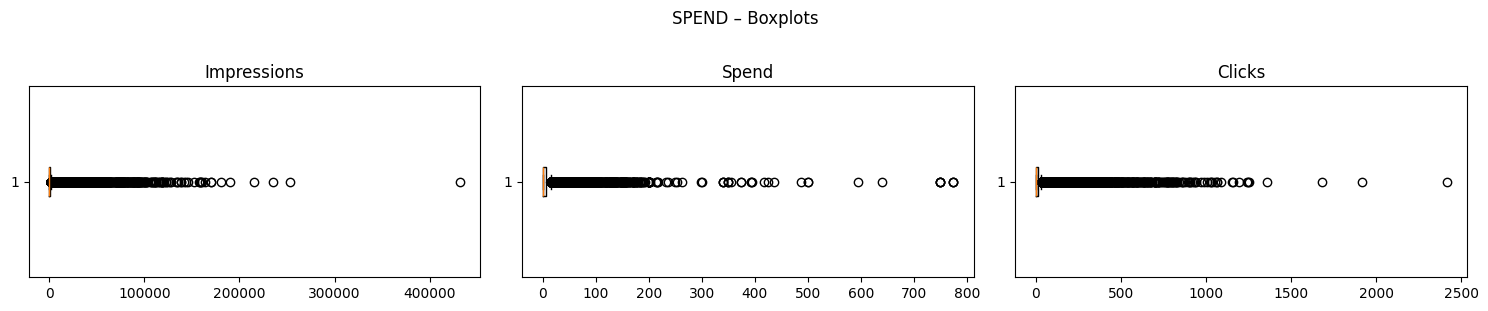

In [17]:
plot_boxplots(
    spend,
    exclude=['Campaign_missing_flag'],
    title_prefix="SPEND"
)

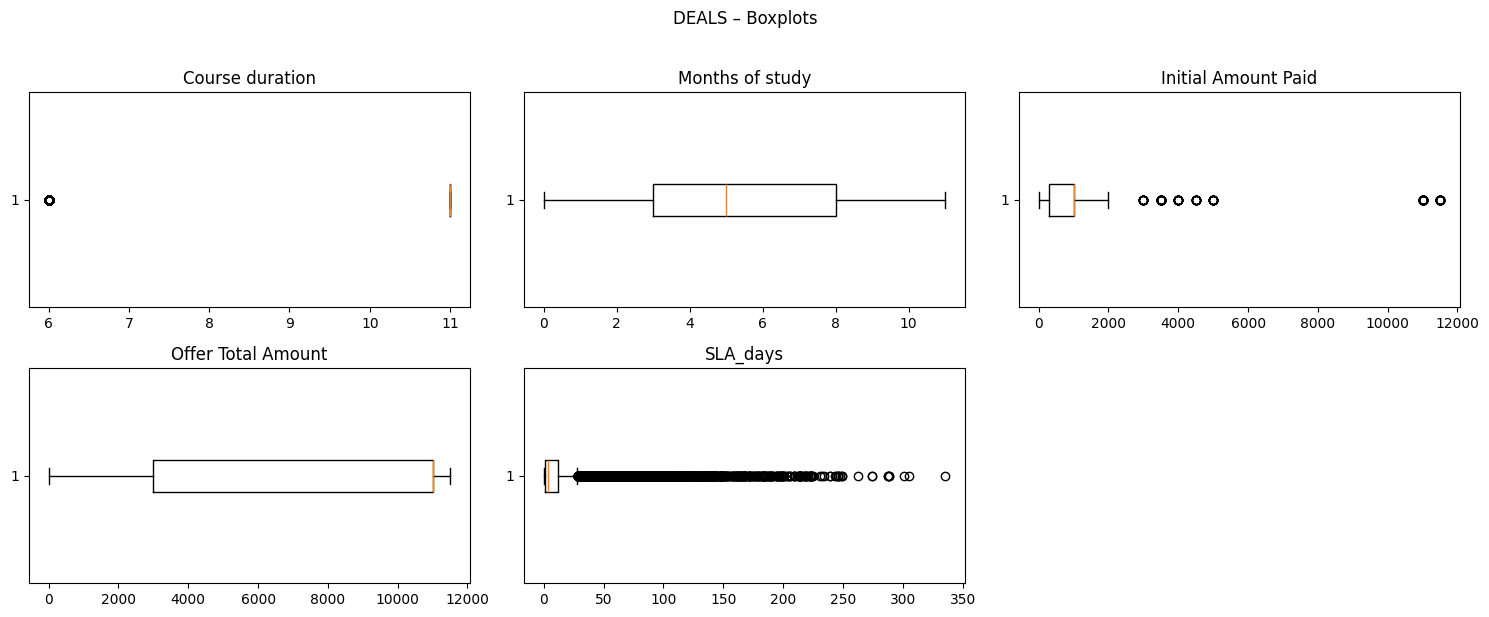

In [18]:
plot_boxplots(
    deals,
    exclude=[
        'Id',
        'Contact Name',
        'SLA_negative_flag',
        'Closed_same_day_flag'
    ],
    title_prefix="DEALS"
)

Für numerische Kennzahlen wurden zusätzlich **Boxplot-Diagramme** erstellt, die eine visuelle Bewertung des **Medians**, des **Interquartilsabstands** sowie möglicher **Ausreißer** ermöglichen. Für die meisten Metriken zeigt sich eine **rechtsschiefe Verteilung**, was mit den Ergebnissen der deskriptiven Statistik übereinstimmt.

### 2.2 Analysieren Sie kategoriale Felder wie Qualität, Phase, Quelle und Produkt.


### Block 1

In [25]:
from IPython.display import display, HTML

def categorical_distribution(df, col):
    vc = df[col].value_counts(dropna=True)
    pct = (vc / vc.sum() * 100).round(2)
    return pd.DataFrame({
        'count': vc,
        'percent_%': pct
    })

tables = [
    categorical_distribution(deals, 'Quality'),
    categorical_distribution(deals, 'Stage'),
    categorical_distribution(deals, 'Product'),
    categorical_distribution(deals, 'Source')
]

html = "<div style='display:flex; gap:20px'>"
for t in tables:
    html += t.to_html()
html += "</div>"

display(HTML(html))

,count,percent_%
Quality,,
E - Non Qualified,7632,39.47
D - Non Target,6248,32.31
C - Low,3459,17.89
B - Medium,1564,8.09
A - High,432,2.23
F,3,0.02
,count,percent_%
Stage,,
Lost,15741,72.91


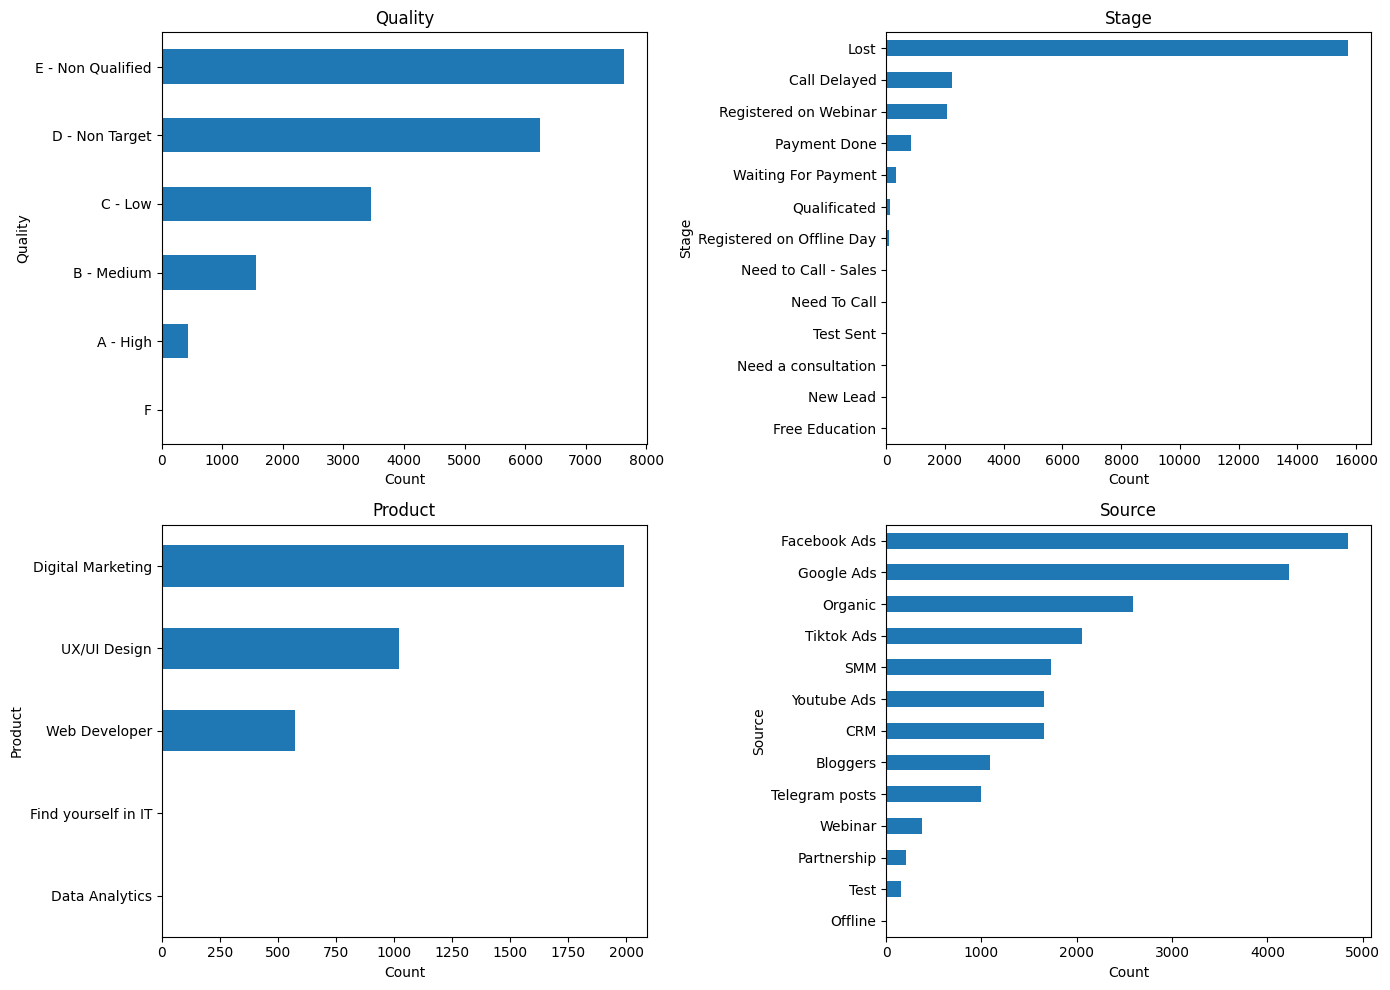

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cols = ['Quality', 'Stage', 'Product', 'Source']

for ax, col in zip(axes, cols):
    vc = deals[col].value_counts(dropna=True)
    vc.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

Für die wichtigsten kategorialen Variablen (**Qualität, Phase, Produkt, Quelle**) wurden **Balkendiagramme** erstellt, die die Verteilung der Deals darstellen. Der Großteil der Leads gehört zu **niedrigen und mittleren Qualitätskategorien**, während die Mehrheit der Deals in der **Phase „Lost“** endet.

### Block 2

In [22]:
# Medianer Kurswert nach Produkt analysieren
deals.groupby('Product')['Offer Total Amount'] \
     .median() \
     .sort_values(ascending=False)

Product
Digital Marketing     11000.00
UX/UI Design          11000.00
Data Analytics         6000.00
Web Developer          5000.00
Find yourself in IT       0.00
Name: Offer Total Amount, dtype: float64

**Berechnung des durchschnittlichen Umsatzes pro Produkt:**

Für die Berechnung des **durchschnittlichen Umsatzes pro Kunde** wurde der tatsächliche Umsatz verwendet, der an die **tatsächlich absolvierten Monate der Ausbildung** angepasst wurde.

* Bei **wiederkehrenden Zahlungen (Recurring Payments)** wurde der Umsatz als Produkt aus **monatlicher Zahlung und Anzahl der absolvierten Monate** berechnet.
* Bei **Einmalzahlungen (One-time Payments)** wurde der Umsatz als **proportionaler Anteil am gesamten Kurspreis** berechnet.

Die Aggregation erfolgte auf **Studentenebene (`Contact Name`)**, wobei **nur Deals mit dem Status „Payment Done“** berücksichtigt wurden.

In [32]:
deals_calc = deals.copy()

# Nur bezahlte Deals behalten
deals_paid = deals_calc[deals_calc['Stage'] == 'Payment Done'].copy()

# Tatsächliche Anzahl der Studienmonate
deals_paid['real_months'] = deals_paid['Months of study']

# Tatsächlichen Umsatz pro Deal berechnen
deals_paid['revenue_fact'] = np.nan

# 1) Recurring Payment: monatliche Zahlung * absolvierte Monate
mask_recurring = deals_paid['Payment Type'] == 'Recurring Payment'
deals_paid.loc[mask_recurring, 'revenue_fact'] = (
    deals_paid.loc[mask_recurring, 'Initial Amount Paid'] *
    deals_paid.loc[mask_recurring, 'real_months']
)

# 2) One Payment: (Gesamtbetrag / Kursdauer) * absolvierte Monate
mask_one = deals_paid['Payment Type'] == 'One Payment'
deals_paid.loc[mask_one, 'revenue_fact'] = (
    deals_paid.loc[mask_one, 'Offer Total Amount'] /
    deals_paid.loc[mask_one, 'Course duration'] *
    deals_paid.loc[mask_one, 'real_months']
)

# ---- Kontrolle: Wo revenue_fact nicht berechnet werden konnte (wegen fehlender Werte) ----
missing_rev = deals_paid['revenue_fact'].isna().sum()
print(f"Payment-Done-Zeilen: {len(deals_paid)}")
print(f"Umsatz nicht berechnet (NaN): {missing_rev}")

# === 1) Medianer „Check“ nach Produkt (auf Deal-Ebene) ===
median_check_by_product_deal = (
    deals_paid
    .dropna(subset=['revenue_fact', 'Product'])
    .groupby('Product')['revenue_fact']
    .median()
    .sort_values(ascending=False)
)

print("\n=== Medianer Check nach Produkt (DEAL-Ebene, nur Payment Done) ===")
print(median_check_by_product_deal)

# === 2) Medianer „Check“ nach Produkt (auf Studentenebene = Contact Name) ===
# Umsatz des Studenten je Produkt aggregieren
# (falls ein Student mehrere Zahlungen/Deals hat)
student_revenue = (
    deals_paid
    .dropna(subset=['revenue_fact', 'Contact Name', 'Product'])
    .groupby(['Contact Name', 'Product'])['revenue_fact']
    .sum()
    .reset_index()
)

median_check_by_product_student = (
    student_revenue
    .groupby('Product')['revenue_fact']
    .median()
    .sort_values(ascending=False)
)

print("\n=== Medianer Check nach Produkt (STUDENTEN-Ebene, nur Payment Done) ===")
print(median_check_by_product_student)

Payment Done rows: 858
Revenue not computed (NaN): 748

=== Median check by Product (DEAL level, Payment Done only) ===
Product
Digital Marketing   1909.09
UX/UI Design        1363.64
Web Developer       1333.33
Name: revenue_fact, dtype: float64

=== Median check by Product (STUDENT level, Payment Done only) ===
Product
Digital Marketing   1909.09
UX/UI Design        1363.64
Web Developer       1333.33
Name: revenue_fact, dtype: float64


In [ ]:
**Diagramm:**
*(Stage = Payment Done, nur Produkte mit ausreichendem Volumen; seltene Produkte werden ausgeschlossen; Kennzahl = Median des tatsächlichen Umsatzes `revenue_fact`)*

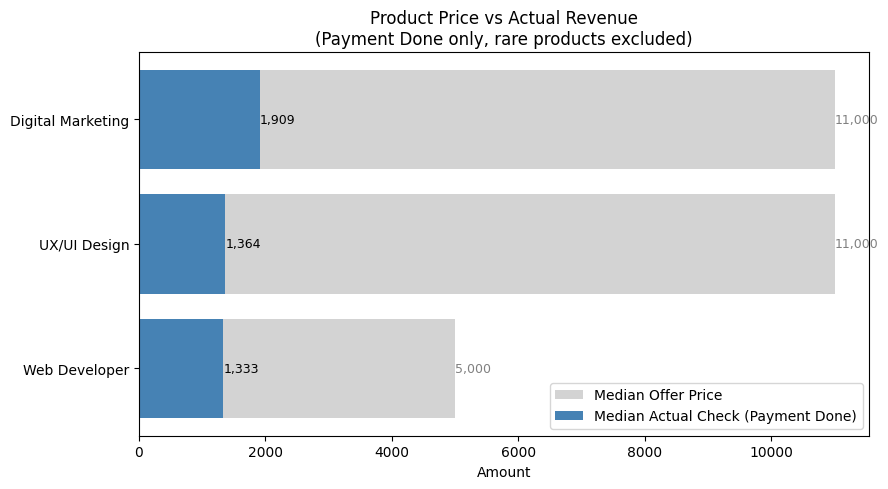

In [39]:
# --- Parameter ---
min_students = 20

# ===== 1) TATSÄCHLICHER CHECK (Payment Done, auf Studentenebene) =====
paid = deals_paid.copy()  # Stage == Payment Done

student_revenue = (
    paid
    .dropna(subset=['revenue_fact', 'Contact Name', 'Product'])
    .groupby(['Contact Name', 'Product'])['revenue_fact']
    .sum()
    .reset_index()
)

product_counts = (
    student_revenue
    .groupby('Product')['Contact Name']
    .nunique()
)

valid_products = product_counts[product_counts >= min_students].index

median_actual = (
    student_revenue[student_revenue['Product'].isin(valid_products)]
    .groupby('Product')['revenue_fact']
    .median()
)

# ===== 2) NOMINALER KURSPREIS =====
median_offer = (
    deals
    .groupby('Product')['Offer Total Amount']
    .median()
)

# ===== 3) ZUSAMMENFÜHREN =====
plot_df = pd.DataFrame({
    'Actual median check': median_actual,
    'Offer median price': median_offer
}).dropna()

plot_df = plot_df.sort_values('Actual median check', ascending=True)

# ===== 4) DIAGRAMM ERSTELLEN =====
plt.figure(figsize=(9, 5))

bars_offer = plt.barh(
    plot_df.index,
    plot_df['Offer median price'],
    color='lightgray',
    label='Median Offer Price'
)

bars_actual = plt.barh(
    plot_df.index,
    plot_df['Actual median check'],
    color='steelblue',
    label='Median Actual Check (Payment Done)'
)

# ===== 5) WERTE BESCHRIFTEN =====
for bar in bars_offer:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va='center',
        ha='left',
        fontsize=9,
        color='gray'
    )

for bar in bars_actual:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va='center',
        ha='left',
        fontsize=9,
        color='black',
    )

plt.xlabel('Betrag')
plt.title(
    'Produktpreis vs. tatsächlicher Umsatz\n'
    '(nur Payment Done, seltene Produkte ausgeschlossen)'
)
plt.legend()
plt.tight_layout()
plt.show()

Für die Produkte wurden der **mediane nominale Kurspreis** und der **mediane tatsächliche Umsatz pro Student** miteinander verglichen. Die Analyse wurde **nur für bezahlte Deals (Payment Done)** durchgeführt und **seltene Produkte wurden ausgeschlossen**.

Der tatsächliche Umsatz pro Student liegt bei allen Produkten **unter dem nominalen Kurspreis**, was den Einfluss der **realen Studiendauer** sowie der **gewählten Zahlungsart** widerspiegelt.

In [40]:
output_path = r"C:\Users\Acer\Projekt\Output"

spend.to_excel(
    f"{output_path}\\spend_cleaned062.xlsx",
    index=False
)

deals.to_excel(
    f"{output_path}\\deals_cleaned062.xlsx",
    index=False
)

calls.to_excel(
    f"{output_path}\\calls_cleaned062.xlsx",
    index=False
)

contacts.to_excel(
    f"{output_path}\\contacts_cleaned062.xlsx",
    index=False
)